# 01 Compare TemporalGP Models

Read the raw SVZ aging h5ad from `datasets/`, extract Microglia, build the temporal kernel, run runtime scaling, and plot panels B/C.

In [14]:
from pathlib import Path
import time

import anndata as ad
import h5py
import numpy as np
import pandas as pd
import torch
import pyro
import matplotlib.pyplot as plt

from GP import TemporalGP
from utils import build_temporal_kernel

pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float32)

PROJECT_DIR = Path(".")
DATA_DIR = Path("datasets")
RAW_H5AD = DATA_DIR / "aging_svz_adata.h5ad"

CELL_TYPE = "Microglia"
CELLTYPE_COL = "Celltype.LowRes"
AGE_COL = "Age"
COHORT_COL = "orig.ident"

MODEL_NAMES = ["GP_MF", "GP_Full-rank", "Indep_MF"]
GENE_NUMS = [100, 200, 300, 500, 1000, 2000, 3000, 5000]
SAVE_FULL_GENE_NUM = 5000
TARGET_GENE = "Bc1"

NUM_STEPS = 1000
LR = 0.005
SEED = 0
CHUNK_ROWS = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"project: {PROJECT_DIR}")
print(f"raw h5ad: {RAW_H5AD}")
print(f"device: {DEVICE}")

project: .
raw h5ad: datasets/aging_svz_adata.h5ad
device: cuda


In [15]:
adata = ad.read_h5ad(RAW_H5AD, backed="r")
obs = adata.obs[[CELLTYPE_COL, AGE_COL, COHORT_COL]].copy()
obs["age"] = pd.to_numeric(obs[AGE_COL].astype(str), errors="raise")
obs["cell_id"] = obs.index.astype(str)
obs["row_index"] = np.arange(adata.n_obs)
obs["celltype"] = obs[CELLTYPE_COL].astype(str)
obs["cohort"] = obs[COHORT_COL].astype(str)

age_values = np.array(sorted(obs["age"].unique()), dtype=float)
age_to_index = {age: i for i, age in enumerate(age_values)}
obs["time_index"] = obs["age"].map(age_to_index).astype(int)

time_kernel, gamma_age, age_z = build_temporal_kernel(age_values)
time_points = pd.DataFrame({
    "time_index": np.arange(len(age_values), dtype=int),
    "age": age_values,
    "age_z": age_z,
})

microglia_obs = (
    obs.loc[obs["celltype"] == CELL_TYPE, ["cell_id", "row_index", "age", "time_index", "cohort"]]
    .sort_values("row_index")
    .reset_index(drop=True)
)
all_genes = adata.var_names.astype(str).to_list()
gene_to_index = {gene: i for i, gene in enumerate(all_genes)}

print(f"{CELL_TYPE}: {microglia_obs.shape[0]} cells, {len(all_genes)} genes, {len(age_values)} time points")
print(f"temporal kernel: {time_kernel.shape}, gamma={gamma_age:.6g}")
microglia_obs.head()

Microglia: 3844 cells, 31053 genes, 26 time points
temporal kernel: (26, 26), gamma=0.53068


,cell_id,row_index,age,time_index,cohort
0,AAACCCAGTCACCACG_1,2,29.0,25,Batch-1
1,AAACCCATCACTGAAC_1,5,20.8,18,Batch-1
2,AAACGCTGTAGGCTCC_1,11,29.0,25,Batch-1
3,AAAGGATCATTGGCAT_1,23,29.0,25,Batch-1
4,AAAGGGCAGCCGAACA_1,26,29.0,25,Batch-1


In [16]:
def _to_dense_array(x):
    if hasattr(x, "toarray"):
        x = x.toarray()
    return np.asarray(x)


def _read_microglia_expression_block(row_indices, gene_names=None):
    row_indices = np.asarray(row_indices, dtype=int)
    if gene_names is None:
        gene_positions = None
    else:
        gene_positions = np.array([gene_to_index[g] for g in gene_names], dtype=int)

    blocks = []
    with h5py.File(RAW_H5AD, "r") as h5:
        X = h5["X"]
        for start in range(0, len(row_indices), CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, len(row_indices))
            # h5py allows only one fancy index vector at a time, so select rows
            # from the backed h5ad first and select gene columns in memory.
            block = _to_dense_array(X[row_indices[start:end], :])
            if gene_positions is not None:
                block = block[:, gene_positions]
            blocks.append(block)
    return np.vstack(blocks)


def select_top_genes_by_mean(max_genes=max(GENE_NUMS)):
    row_indices = microglia_obs["row_index"].to_numpy(dtype=int)
    sums = np.zeros(len(all_genes), dtype=np.float64)
    with h5py.File(RAW_H5AD, "r") as h5:
        X = h5["X"]
        for start in range(0, len(row_indices), CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, len(row_indices))
            block = _to_dense_array(X[row_indices[start:end], :])
            sums += block.sum(axis=0)
    means = pd.Series(sums / len(row_indices), index=all_genes)
    return means.sort_values(ascending=False).head(int(max_genes)).index.tolist()


top_genes = select_top_genes_by_mean()
print(f"selected {len(top_genes)} top genes by Microglia mean expression")
print(f"{TARGET_GENE} in top {SAVE_FULL_GENE_NUM}: {TARGET_GENE in top_genes[:SAVE_FULL_GENE_NUM]}")

selected 5000 top genes by Microglia mean expression
Bc1 in top 5000: True


In [17]:
def load_microglia_subset(genes, device=DEVICE):
    genes = list(genes)
    missing = sorted(set(genes) - set(all_genes))
    if missing:
        raise ValueError(f"Missing genes in h5ad var_names: {missing[:10]}")

    row_indices = microglia_obs["row_index"].to_numpy(dtype=int)
    Y_np = _read_microglia_expression_block(row_indices, genes).astype("float32")
    if not np.issubdtype(Y_np.dtype, np.integer) and np.allclose(Y_np, np.rint(Y_np)):
        Y_np = np.rint(Y_np).astype("float32")

    library_size = _read_microglia_expression_block(row_indices, None).sum(axis=1).astype("float32")
    time_index = microglia_obs["time_index"].to_numpy(dtype="int64")

    Y, time_index_t, time_kernel_t, library_size_t = TemporalGP.prepare_inputs(
        Y_np,
        time_index,
        time_kernel.astype("float32"),
        library_size,
        device=device,
    )
    return {
        "Y": Y,
        "time_index": time_index_t,
        "time_kernel": time_kernel_t,
        "library_size": library_size_t,
        "cell_ids": microglia_obs["cell_id"].tolist(),
        "genes": genes,
        "cell_type": CELL_TYPE,
    }


def fit_one_model(model_name, genes):
    pyro.set_rng_seed(SEED)
    data = load_microglia_subset(genes)
    model = TemporalGP(model_name=model_name)

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    losses = model.fit(
        data["Y"],
        data["time_index"],
        data["time_kernel"],
        data["library_size"],
        num_steps=NUM_STEPS,
        lr=LR,
        clear_param_store=True,
        print_every=0,
        device=DEVICE,
    )
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    runtime_seconds = time.perf_counter() - t0

    metrics = {
        "cell_type": CELL_TYPE,
        "model_name": model_name,
        "gene_num": len(data["genes"]),
        "cell_num": len(data["cell_ids"]),
        "num_steps": NUM_STEPS,
        "lr": LR,
        "seed": SEED,
        "device": DEVICE,
        "runtime_seconds": float(runtime_seconds),
        "runtime_minutes": float(runtime_seconds / 60.0),
        "initial_loss": float(losses[0]),
        "final_loss": float(losses[-1]),
    }
    return {
        "metrics": metrics,
        "params": TemporalGP.collect_param_store(),
        "posterior": TemporalGP.get_posterior_means(),
        "losses": losses,
        "genes": data["genes"],
        "cell_ids": data["cell_ids"],
        "time_points": time_points.copy(),
    }

In [18]:
def run_runtime_experiment():
    rows = []
    model_results_5000 = {}
    target_gene_results = {}

    for gene_num in GENE_NUMS:
        genes = top_genes[:gene_num]
        for model_name in MODEL_NAMES:
            print(f"Running {model_name} with {gene_num} genes")
            result = fit_one_model(model_name, genes)
            rows.append(result["metrics"])
            if gene_num == SAVE_FULL_GENE_NUM:
                model_results_5000[model_name] = result

    runtime_summary = pd.DataFrame(rows).sort_values(["gene_num", "model_name"]).reset_index(drop=True)
    if TARGET_GENE not in top_genes[:SAVE_FULL_GENE_NUM] and TARGET_GENE in all_genes:
        for model_name in MODEL_NAMES:
            print(f"Running {model_name} for {TARGET_GENE}")
            target_gene_results[model_name] = fit_one_model(model_name, [TARGET_GENE])
    return runtime_summary, model_results_5000, target_gene_results



runtime_summary, model_results_5000, target_gene_results = run_runtime_experiment()

Running GP_MF with 100 genes


Running GP_Full-rank with 100 genes
Running Indep_MF with 100 genes
Running GP_MF with 200 genes
Running GP_Full-rank with 200 genes
Running Indep_MF with 200 genes
Running GP_MF with 300 genes
Running GP_Full-rank with 300 genes
Running Indep_MF with 300 genes
Running GP_MF with 500 genes
Running GP_Full-rank with 500 genes
Running Indep_MF with 500 genes
Running GP_MF with 1000 genes
Running GP_Full-rank with 1000 genes
Running Indep_MF with 1000 genes
Running GP_MF with 2000 genes
Running GP_Full-rank with 2000 genes
Running Indep_MF with 2000 genes
Running GP_MF with 3000 genes
Running GP_Full-rank with 3000 genes
Running Indep_MF with 3000 genes
Running GP_MF with 5000 genes
Running GP_Full-rank with 5000 genes
Running Indep_MF with 5000 genes


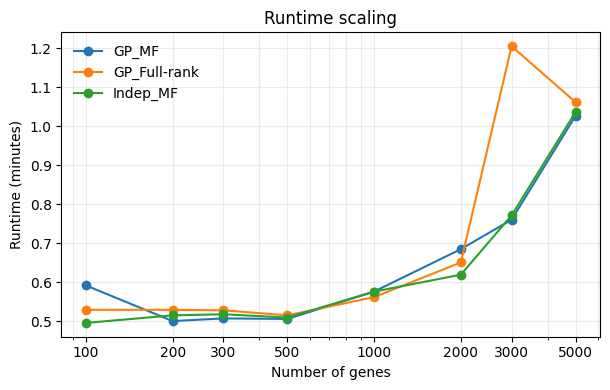

In [19]:
def plot_runtime(runtime_summary):
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for model_name in MODEL_NAMES:
        sub = runtime_summary[runtime_summary["model_name"] == model_name].sort_values("gene_num")
        ax.plot(sub["gene_num"], sub["runtime_minutes"], marker="o", label=model_name)
    ax.set_xscale("log")
    ax.set_xticks(GENE_NUMS)
    ax.set_xticklabels([str(x) for x in GENE_NUMS])
    ax.set_xlabel("Number of genes")
    ax.set_ylabel("Runtime (minutes)")
    ax.set_title("Runtime scaling")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


plot_runtime(runtime_summary)

In [20]:
def compute_b_posterior_sd(result):
    params = result["params"]
    if "guide_b_scale" in params:
        return params["guide_b_scale"].detach().cpu().float().numpy()
    if "guide_b_scale_tril" in params:
        tril = params["guide_b_scale_tril"].detach().cpu().float()
        return torch.sqrt((tril ** 2).sum(dim=-1)).numpy()
    raise ValueError("No supported B posterior scale parameter found.")


def credible_band_width_table(model_results_5000):
    rows = []
    for model_name in MODEL_NAMES:
        result = model_results_5000[model_name]
        b_sd = compute_b_posterior_sd(result)
        width = 2.0 * 1.96 * b_sd
        mean_width = width.mean(axis=1)
        for gene, value in zip(result["genes"], mean_width):
            rows.append({
                "model_name": model_name,
                "gene": gene,
                "mean_95_credible_band_width": float(value),
            })
    return pd.DataFrame(rows)


def target_gene_table(model_results_5000, target_gene_results=None):
    rows = []
    target_gene_results = target_gene_results or {}
    for model_name in MODEL_NAMES:
        if TARGET_GENE in model_results_5000[model_name]["genes"]:
            result = model_results_5000[model_name]
        else:
            result = target_gene_results[model_name]
        genes = list(result["genes"])
        gene_idx = genes.index(TARGET_GENE)
        b_mean = result["params"]["guide_b_loc"].detach().cpu().float().numpy()[gene_idx]
        b_sd = compute_b_posterior_sd(result)[gene_idx]
        for t, (mean, sd) in enumerate(zip(b_mean, b_sd)):
            rows.append({
                "model_name": model_name,
                "gene": TARGET_GENE,
                "time_index": int(t),
                "posterior_mean": float(mean),
                "lower_95": float(mean - 1.96 * sd),
                "upper_95": float(mean + 1.96 * sd),
            })
    return pd.DataFrame(rows)

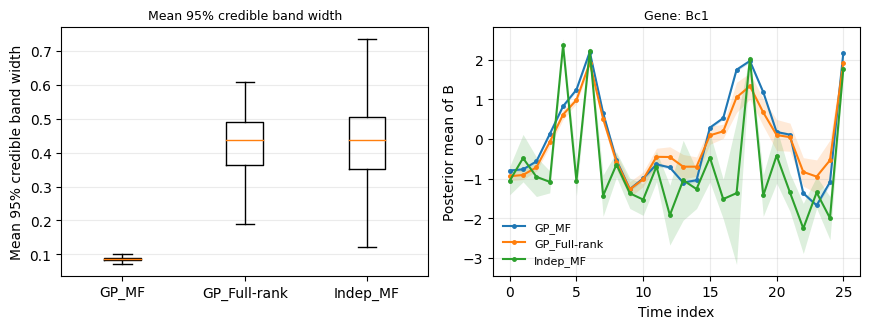

In [21]:
def plot_panels_b1c(model_results_5000, target_gene_results=None):
    width_df = credible_band_width_table(model_results_5000)
    gene_df = target_gene_table(model_results_5000, target_gene_results)

    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.4))

    box_data = [
        width_df.loc[width_df["model_name"] == model_name, "mean_95_credible_band_width"].to_numpy()
        for model_name in MODEL_NAMES
    ]
    axes[0].boxplot(box_data, labels=MODEL_NAMES, showfliers=False)
    axes[0].set_title("Mean 95% credible band width", fontsize=9)
    axes[0].set_ylabel("Mean 95% credible band width")
    axes[0].grid(axis="y", alpha=0.25)

    ax = axes[1]
    for model_name in MODEL_NAMES:
        sub = gene_df[gene_df["model_name"] == model_name].sort_values("time_index")
        x = sub["time_index"].to_numpy()
        mean = sub["posterior_mean"].to_numpy()
        lo = sub["lower_95"].to_numpy()
        hi = sub["upper_95"].to_numpy()
        line = ax.plot(x, mean, marker="o", markersize=2.5, linewidth=1.5, label=model_name)[0]
        ax.fill_between(x, lo, hi, color=line.get_color(), alpha=0.16, linewidth=0)
    ax.set_title(f"Gene: {TARGET_GENE}", fontsize=9)
    ax.set_xlabel("Time index")
    ax.set_ylabel("Posterior mean of B")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    plt.show()
    return width_df, gene_df


width_df, gene_df = plot_panels_b1c(model_results_5000, target_gene_results)